<h2 align="center"><b><i>Simple Linear Regression</i></b></h2>

   *One independent variable (X) → One dependent variable (Y)*                                                     

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
data = pd.read_csv('data.csv')
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [29]:
data.shape

(30, 2)

In [30]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [31]:
data.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [32]:
data.isnull().sum().sum()

np.int64(0)

In [33]:
data.duplicated().sum()

np.int64(0)

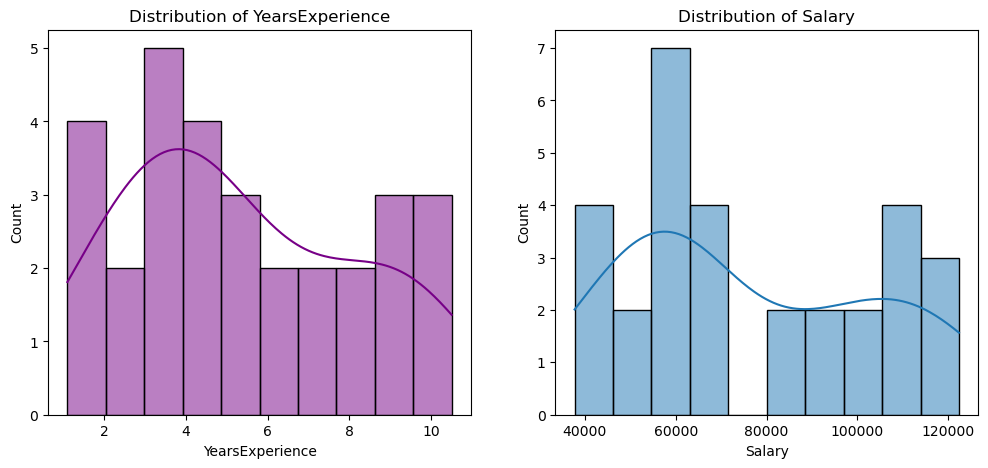

In [34]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data['YearsExperience'],kde=True,bins=10,color='#770087')
plt.title("Distribution of YearsExperience")

plt.subplot(1,2,2)
sns.histplot(data['Salary'],kde=True,bins=10)
plt.title('Distribution of Salary')
plt.show()

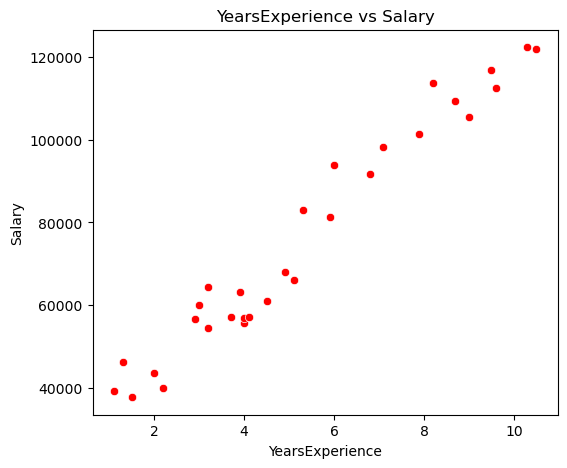

In [35]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='YearsExperience',y='Salary',data=data,color='red')
plt.title('YearsExperience vs Salary')
plt.show()

 # Let's find correlation

     - Correlation measures the strength and direction of the linear relationship between two variables.

       It’s expressed as a number between -1 and +1:

               +1 → Perfect positive correlation (as one increases, the other increases proportionally).

                0 → No linear correlation (no clear relationship).

               -1 → Perfect negative correlation (as one increases, the other decreases proportionally).''

In [36]:
print("Correlation:",data['YearsExperience'].corr(data['Salary']))

Correlation: 0.9782416184887599


A correlation of **0.97** between YearsExperience and Salary means there is an extremely strong positive linear relationship between the two variables.

    - Here’s how to interpret it:

           🔼Positive: As YearsExperience increases, Salary also tends to increase.

           💪Strength: 0.97 is very close to +1, which indicates the relationship is almost perfectly linear. In other words, the data points               lie very close to a straight line.

           📈Implication for regression: A linear regression model is an excellent choice here, because the correlation suggests that                       experience explains most of the variation in salary.

In [37]:
#EDA Part is done -- Let's go for Model building

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [39]:
x = data[['YearsExperience']] #x should always be in 2D format so double brackets[[]]
y = data['Salary']

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.4,random_state=30)

In [41]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [42]:
y_pred = model.predict(x_test)

In [43]:
#Let's compare our predicted values with Actual values
df = pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred})
df

,Actual,Predicted
0,67938.0,72214.039271
1,122391.0,124336.834374
2,116969.0,116614.938803
3,63218.0,62561.669808
4,109431.0,108893.043232
5,39343.0,35535.035310
6,64445.0,55805.011183
7,60150.0,53874.537290
8,105582.0,111788.754071
9,39891.0,46152.641720


In [44]:
r2_score(y_test,y_pred)

0.9711972306949996

In [45]:
mse = mean_squared_error(y_test,y_pred)
print("MSE:",mse)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

MSE: 24082888.81460854
RMSE: 4907.431997960699


In [46]:
# Coefficients
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 24917.42890000523
Slope: 9652.369463466805


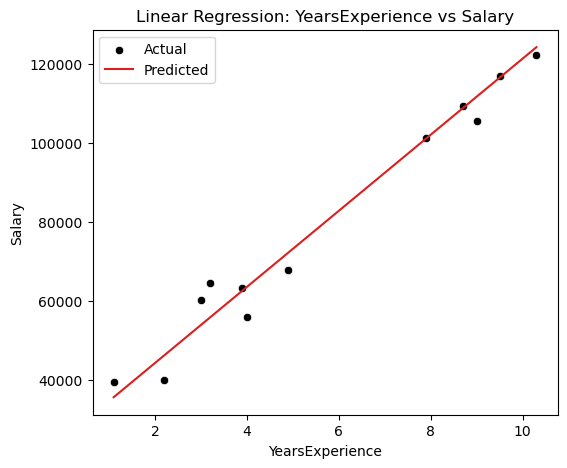

In [47]:
#Plot regression line
plt.figure(figsize=(6,5))
sns.scatterplot(x = x_test['YearsExperience'], y = y_test,color='black',label='Actual')
sns.lineplot(x = x_test['YearsExperience'], y = y_pred,color='#dc1e1e',label='Predicted')
plt.title("Linear Regression: YearsExperience vs Salary")
plt.show()

# We can predict salary by randomly giving YearsExp

In [48]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [49]:
exp = [[15]] #input must be 2D
pred = model.predict(exp)
print("Predicted Salary for 15 years of experience:", pred[0])

Predicted Salary for 15 years of experience: 169702.9708520073


In [50]:
#[0] is just array indexing.
#It extracts the first element from the prediction array.
#Without [0], you’ll see the result as [value] (inside brackets). With [0], you get the raw number.

In [51]:
exp = int(input("Enter Years of Experience in numbers to predict the salary: "))
pred = model.predict([[exp]])
print(f"Predicted salary for {exp} is {pred}")

Enter Years of Experience in numbers to predict the salary:  20


Predicted salary for 20 is [217964.81816934]


 **What Simple Linear Regression Does**
 
    --It fits a straight line to your data:
          Salary = 𝛽0 + 𝛽1.YearsExperience
🔸𝛽0 → Intercept (salary when experience = 0)
🔸𝛽1 → Slope (increase in salary per year of experience)

                                           ----------------------------------------------------

                                           ----------------------------------------------------

                                           ----------------------------------------------------

<h2 align="center"><b><i>Multiple Linear Regression</i></b></h2>

*Two or more independent variables (X₁, X₂, …) → One dependent variable (Y)*

In [52]:
df = pd.read_csv('Housing.csv')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [54]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [55]:
df.isnull().sum().sum()

np.int64(0)

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.shape

(21613, 21)

In [58]:
# Checking outliers
'''for i in df.columns:
  if df[i].dtype!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()'''

"for i in df.columns:\n  if df[i].dtype!='object':\n    plt.boxplot(df[i])\n    plt.xlabel(i)\n    plt.show()"

In [59]:
# Drop unwanted columns

df = df.drop(columns=['id', 'date'],axis=1)

In [60]:
df.head(3)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


In [61]:
#Feature engineering -  - Create useful new features if needed

In [62]:
#Check multicollinearity - Remove highly correlated features (use correlation / VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor

col_list=[]
for i in df.columns:
  if (i!='Price'):
   col_list.append(i)
#Apply vif
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_name']=X.columns
vif_data['VIF_score']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif_data

C:\Anaconda\Prashanthh\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column_name,VIF_score
0,price,1.053622e+01
1,bedrooms,2.365334e+01
2,bathrooms,2.882280e+01
3,sqft_living,inf
4,sqft_lot,2.378510e+00
5,floors,1.689394e+01
6,waterfront,1.276220e+00
7,view,1.595318e+00
8,condition,3.493203e+01
9,grade,1.608968e+02


**When SHOULD you remove features?**

 *Remove a feature only if:*
 
       -VIF >= 6 (sometimes > 10)
       
       -AND it is highly correlated with another feature

Remove columns one by one which has more vif score by repeatedly checking vif.

Here we have sqft_living,sqft_above,sqft_basement has inf(infinity). Remove one col and check vif, again if it is >5 remove -repeat the process

In [63]:
df = df.drop(columns=['sqft_living'])

In [64]:
col_list=[]
for i in df.columns:
  if (i!='Price'):
   col_list.append(i)
#Apply vif
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_name']=X.columns
vif_data['VIF_score']=[variance_inflation_factor(X.values,i) for i in range(len(X.columns))]
vif_data

,Column_name,VIF_score
0,price,1.053622e+01
1,bedrooms,2.365334e+01
2,bathrooms,2.882280e+01
3,sqft_lot,2.378510e+00
4,floors,1.689394e+01
5,waterfront,1.276220e+00
6,view,1.595318e+00
7,condition,3.493203e+01
8,grade,1.608968e+02
9,sqft_above,3.098082e+01


In [65]:
x = df.drop(columns=['price'])
y = df['price']

In [78]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [79]:
model.fit(x_train,y_train)

LinearRegression()

In [80]:
y_pred = model.predict(x_test)

In [81]:
r2_score(y_test,y_pred)

0.6994627079172884

In [83]:
mse = mean_squared_error(y_test,y_pred)
print("MSE:",mse)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

MSE: 43387527199.87119
RMSE: 208296.72873060487


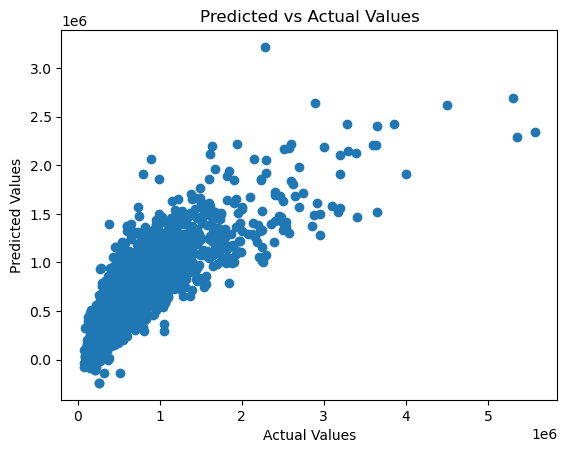

In [84]:
# Predicted vs Actual
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.show()

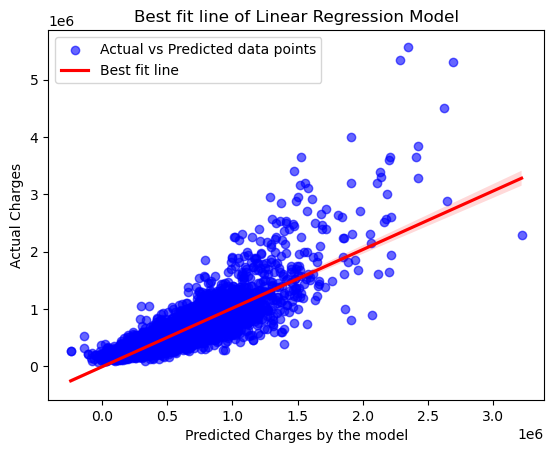

In [93]:
sns.regplot(
    x=y_pred,
    y=y_test,
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.xlabel('Predicted Charges by the model')
plt.ylabel('Actual Charges')
plt.title('Best fit line of Linear Regression Model')
plt.legend(['Actual vs Predicted data points','Best fit line'])
plt.show()

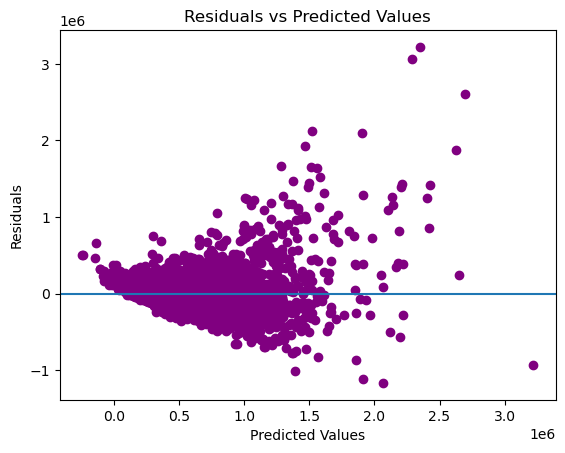

In [85]:
# Calculate residuals/error
error = y_test - y_pred

# Residuals vs Predicted
plt.figure()
plt.scatter(y_pred, error,color='purple')
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

In [73]:
# ===== STEPS / CHECKS TO BUILD A LINEAR REGRESSION MODEL =====

# 1. Understand the data
#    - Check number of rows and columns
#    - Identify target variable (y) and features (X)

# 2. Remove unwanted columns
#    - Drop ID, date, or columns with no predictive value

# 3. Check missing values
#    - Fill or remove NaN values (LR cannot handle missing data)

# 4. Check data types
#    - Convert categorical variables into numeric (encoding)

# 5. Perform Exploratory Data Analysis (EDA)
#    - Understand data distribution
#    - Check relationship between features and target

# 6. Check and handle outliers
#    - Extreme values can badly affect LR performance

# 7. Feature engineering
#    - Create useful new features (e.g., house_age, sqft_per_room)

# 8. Feature scaling (important)
#    - Scale features using StandardScaler or MinMaxScaler

# 9. Check multicollinearity
#    - Remove highly correlated features (use correlation / VIF)

# 10. Split data into train and test sets
#     - Example: 80% training, 20% testing

# 11. Check linear regression assumptions
#     - Linearity
#     - Normality of residuals
#     - Homoscedasticity
#     - No multicollinearity

# 12. Build the Linear Regression model
#     - Fit model using training data

# 13. Evaluate the model
#     - Check R² score, MAE, MSE, RMSE

# 14. Interpret results
#     - Analyze coefficients and residual plots

# ===== END =====
